In [1]:
from scripts.visualizer.main import Visualizer
from scripts.helper.make_polygons import make_polygons
from scripts.helper.triangulate_y_monotone import triangulate_y_monotone

In [2]:
def draw_polygon_tri(polygon, tri):
    vis = Visualizer()
    points = polygon
    tri_line_segments = tri
    vis.add_polygon(points, fill=False)
    vis.add_point(points)
    vis.add_line_segment(tri_line_segments, color="red")
    vis.show()

In [3]:
def draw_polygon(polygon: list[tuple[float, float]]) -> None:
    vis = Visualizer()
    vis.add_polygon(polygon, fill=False)
    vis.show()

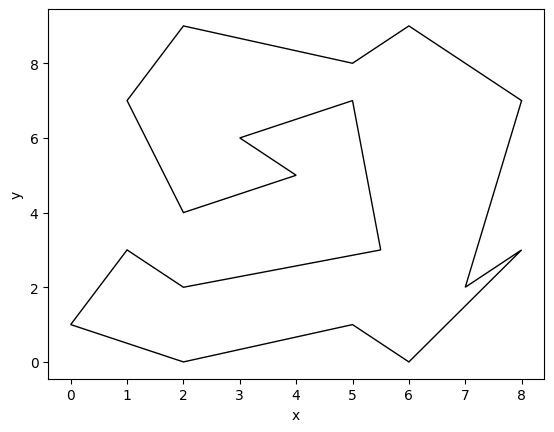

In [4]:
polygon_example1 = [
    (2, 0),
    (5, 1),
    (6, 0),
    (8, 3),
    (7, 2),
    (8, 7),
    (6, 9),
    (5, 8),
    (2, 9),
    (1, 7),
    (2, 4),
    (4, 5),
    (3, 6),
    (5, 7),
    (5.5, 3),
    (2, 2),
    (1, 3),
    (0, 1),
]
draw_polygon(polygon_example1)



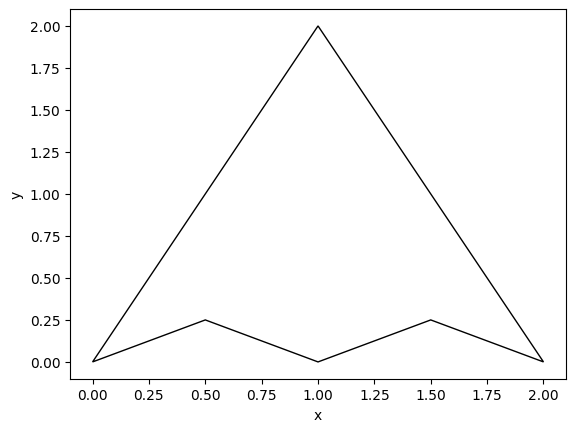

In [5]:
polygon_example2 = [
    (0,0),
    (0.5, 0.25),
    (1, 0),
    (1.5, 0.25),
    (2, 0),
    (1, 2)
]
draw_polygon(polygon_example2)

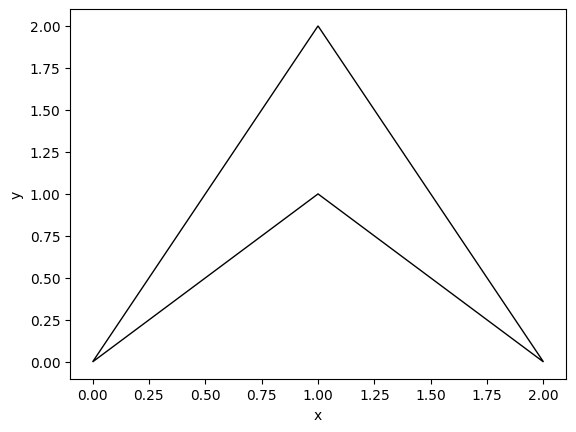

In [6]:
polygon_example3 = [
    (0,0),
    (1, 1),
    (2, 0),
    (1, 2)
]
draw_polygon(polygon_example3)

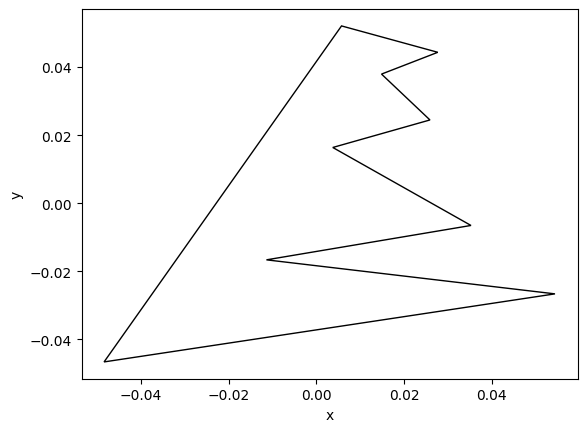

In [7]:
polygon_example4 = [
        (0.03523160349938177, -0.0065379891676061175),
        (0.0037396680155108025, 0.01637867749906055),
        (0.025884829305833385, 0.02446691279317821),
        (0.014848538983252729, 0.03794730495004095),
        (0.02767111962841403, 0.04435049122455076),
        (0.005735635757446289, 0.05210171671474684),
        (-0.04837726746836017, -0.0466421558342728),
        (0.05437726746836017, -0.0266421558342728),
        (-0.01137726746836017, -0.0166421558342728),
    ]
draw_polygon(polygon_example4)

## Choose polygon

In [8]:
polygon = polygon_example1

## Run

In [9]:
monotone_polygons = make_polygons(polygon)
triangulations: list[
    tuple[list[tuple[float, float]], list[tuple[tuple[float, float], tuple[float, float]]]]
] = []  # (polygon(x,y), [diagonal((x1,y1), (x2,y2)), ...])
for monotone_polygon in monotone_polygons:
    triangulations.append((monotone_polygon, triangulate_y_monotone(monotone_polygon)))

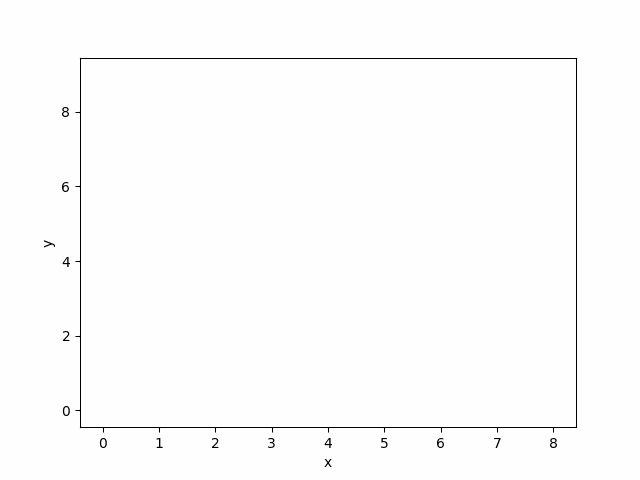

In [10]:
vis = Visualizer()
vis.add_polygon(polygon, fill=True, color="lightgray")
for monotone_polygon, diagonals in triangulations:
    vis.add_polygon(monotone_polygon, fill=False, color="red")
    vis.add_line_segment(diagonals, color="purple")
for i in range(10):  # hold gif
    vis.add_point(())
vis.show_gif(interval=400)